In [3]:
import pandas as pd


In [4]:
bio = pd.read_csv('/home/camilo/figuras_mauro/data/cleaned_soundscape.csv')
riqueza = pd.read_csv('/home/camilo/figuras_mauro/data/riqueza_especies.csv')

In [3]:
bio

,id,fecha,hora,Anthrophony,Biophony,Geophony,Quiet,Interference,datetime,site
0,SMM09245,20230928,0,17,0,27,30,30,2023-09-28 00:00:00,P40_SMM09245
1,SMM09245,20230928,500,11,0,28,30,30,2023-09-28 00:05:00,P40_SMM09245
2,SMM09245,20230928,1000,7,0,29,30,30,2023-09-28 00:10:00,P40_SMM09245
3,SMM09245,20230928,1500,13,0,25,30,30,2023-09-28 00:15:00,P40_SMM09245
4,SMM09245,20230928,2000,7,1,22,30,30,2023-09-28 00:20:00,P40_SMM09245
...,...,...,...,...,...,...,...,...,...,...
96763,SMM09721,20231013,233500,1,8,12,29,30,2023-10-13 23:35:00,P01_SMM09721
96764,SMM09721,20231013,234000,3,3,14,29,30,2023-10-13 23:40:00,P01_SMM09721
96765,SMM09721,20231013,234500,2,0,16,30,30,2023-10-13 23:45:00,P01_SMM09721
96766,SMM09721,20231013,235000,0,0,25,28,30,2023-10-13 23:50:00,P01_SMM09721


In [4]:
riqueza

,datetime_5min,site,species_count
0,2023-09-28 00:00:00,P04_SMM09557,0
1,2023-09-28 00:00:00,P01_SMM09721,0
2,2023-09-28 00:00:00,P03_SMM09499,0
3,2023-09-28 00:00:00,P02_SMM09261,0
4,2023-09-28 00:00:00,P13_SMM09539,0
...,...,...,...
96763,2023-10-13 23:55:00,P35_SMM09330,0
96764,2023-10-13 23:55:00,P37_SMM09595,0
96765,2023-10-13 23:55:00,P41_SMM09350,0
96766,2023-10-13 23:55:00,P34_SMM09565,0


In [5]:
# Primero, renombramos la columna datetime_5min para hacer merge más fácil, si es necesario
riqueza = riqueza.rename(columns={'datetime_5min': 'datetime'})

# Hacemos el merge para añadir species_count al DataFrame bio
bio_merge = bio.merge(riqueza[['datetime', 'site', 'species_count']],
                      on=['datetime', 'site'],
                      how='left')

# Creamos la nueva columna con denominador species_count + 1
bio_merge['biophony_per_species'] = bio_merge['Biophony'] / (bio_merge['species_count'] + 1)

# Si quieres actualizar tu DataFrame original
bio = bio_merge


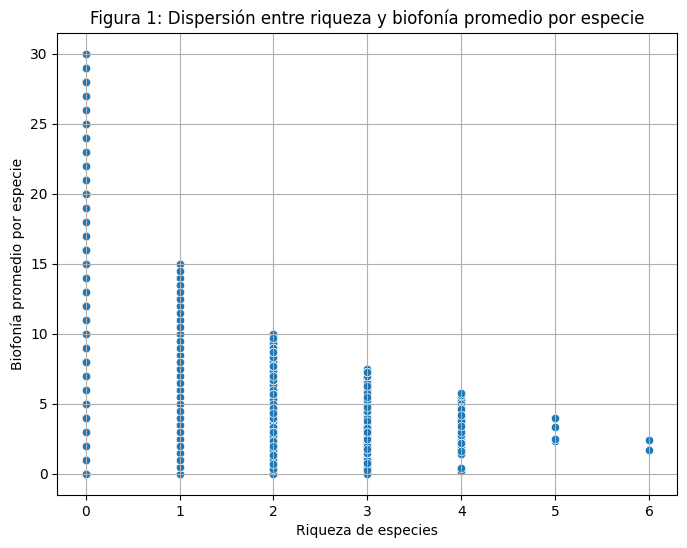

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asumiendo que tu DataFrame 'bio' ya tiene la columna 'biophony_per_species'

plt.figure(figsize=(8,6))
sns.scatterplot(x='species_count', y='biophony_per_species', data=bio)
plt.xlabel('Riqueza de especies')
plt.ylabel('Biofonía promedio por especie')
plt.title('Figura 1: Dispersión entre riqueza y biofonía promedio por especie')
plt.grid(True)
plt.show()


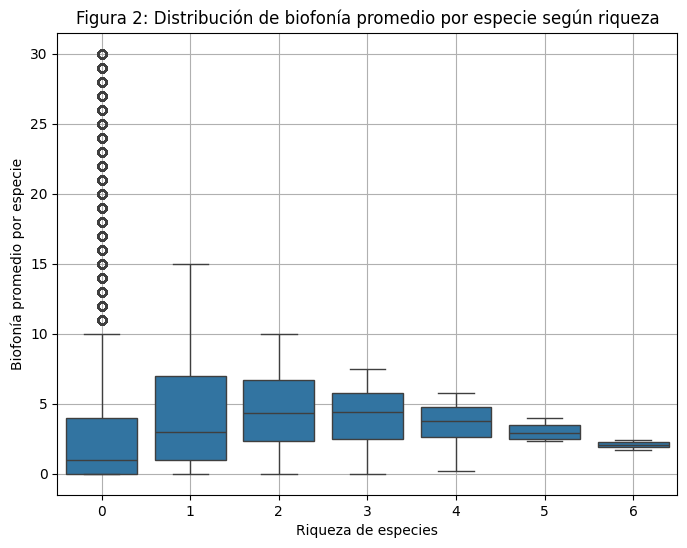

In [9]:
plt.figure(figsize=(8,6))
sns.boxplot(x='species_count', y='biophony_per_species', data=bio)
plt.xlabel('Riqueza de especies')
plt.ylabel('Biofonía promedio por especie')
plt.title('Figura 2: Distribución de biofonía promedio por especie según riqueza')
plt.grid(True)
plt.show()


       species_count  biophony_per_species
count   96768.000000          96768.000000
mean        0.215629              3.678347
std         0.514133              5.692134
min         0.000000              0.000000
25%         0.000000              0.000000
50%         0.000000              1.000000
75%         0.000000              5.000000
max         6.000000             30.000000


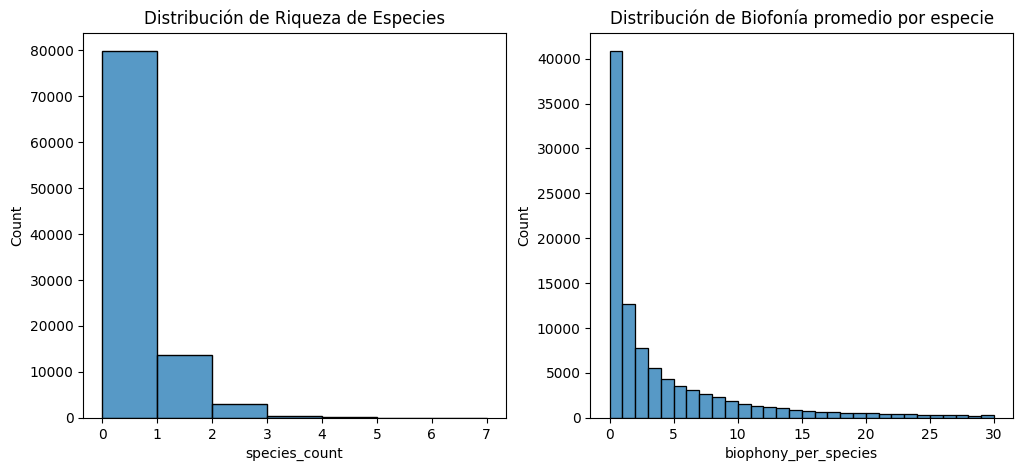

Correlación Pearson: 0.055 (p=5.58e-65)
Correlación Spearman: 0.248 (p=0)


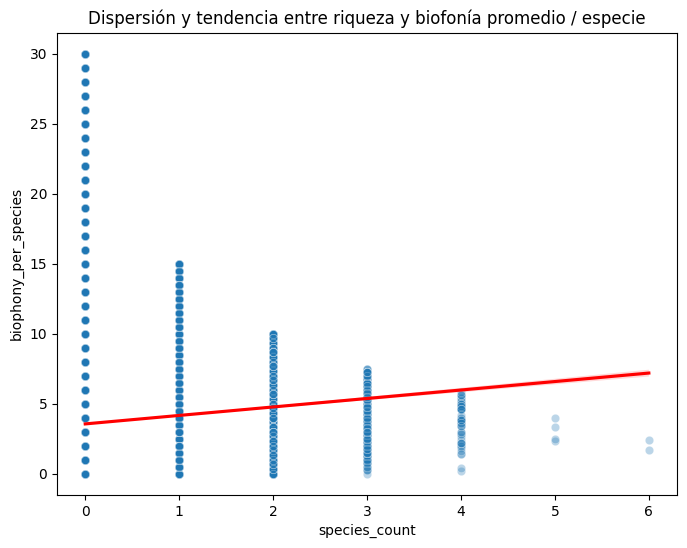

Puntos con alta biofonía pero baja riqueza: 0
Empty DataFrame
Columns: [datetime, site, species_count, biophony_per_species]
Index: []


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Estadísticas descriptivas
print(bio[['species_count', 'biophony_per_species']].describe())

# Histogramas
fig, axs = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(bio['species_count'], bins=range(0, bio['species_count'].max()+2), ax=axs[0])
axs[0].set_title('Distribución de Riqueza de Especies')
sns.histplot(bio['biophony_per_species'], bins=30, ax=axs[1])
axs[1].set_title('Distribución de Biofonía promedio por especie')
plt.show()

# Correlaciones
pearson_corr, p_val_pearson = pearsonr(bio['species_count'], bio['biophony_per_species'])
spearman_corr, p_val_spearman = spearmanr(bio['species_count'], bio['biophony_per_species'])
print(f"Correlación Pearson: {pearson_corr:.3f} (p={p_val_pearson:.3g})")
print(f"Correlación Spearman: {spearman_corr:.3f} (p={p_val_spearman:.3g})")

# Gráfico de dispersión con línea de tendencia
plt.figure(figsize=(8,6))
sns.scatterplot(x='species_count', y='biophony_per_species', data=bio, alpha=0.3)
sns.regplot(x='species_count', y='biophony_per_species', data=bio, scatter=False, color='red')
plt.title('Dispersión y tendencia entre riqueza y biofonía promedio / especie')
plt.show()

# Identificación de outliers simples (ejemplo)
threshold_high_bio = bio['biophony_per_species'].quantile(0.95)
threshold_low_rich = bio['species_count'].quantile(0.05)
outliers = bio[(bio['biophony_per_species'] > threshold_high_bio) & (bio['species_count'] < threshold_low_rich)]
print(f"Puntos con alta biofonía pero baja riqueza: {len(outliers)}")
print(outliers[['datetime', 'site', 'species_count', 'biophony_per_species']].head())


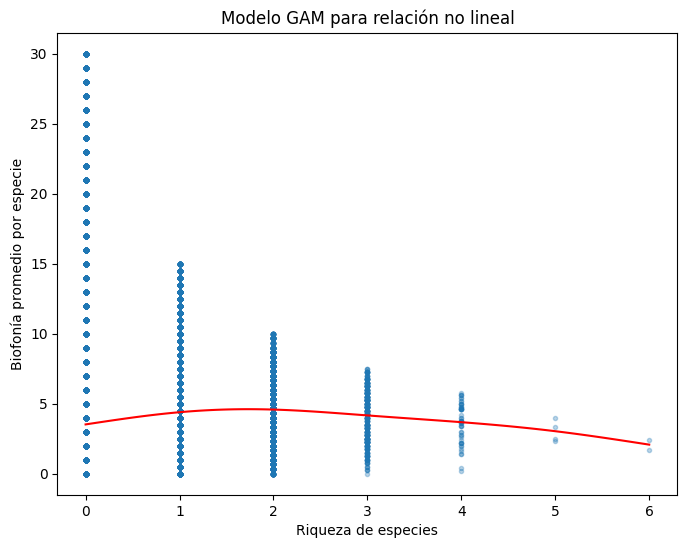

In [12]:
from pygam import LinearGAM, s
import numpy as np

X = bio['species_count'].values.reshape(-1,1)
y = bio['biophony_per_species'].values

gam = LinearGAM(s(0)).fit(X, y)
XX = np.linspace(X.min(), X.max(), 100)
plt.figure(figsize=(8,6))
plt.plot(X, y, '.', alpha=0.3)
plt.plot(XX, gam.predict(XX), 'r')
plt.xlabel('Riqueza de especies')
plt.ylabel('Biofonía promedio por especie')
plt.title('Modelo GAM para relación no lineal')
plt.show()


In [6]:
import statsmodels.formula.api as smf

# Suponiendo que 'site' y 'date' están en tu DataFrame bio
model = smf.mixedlm("biophony_per_species ~ species_count", bio, groups=bio["site"])
result = model.fit()
print(result.summary())


              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: biophony_per_species
No. Observations: 96768   Method:             REML                
No. Groups:       21      Scale:              29.7092             
Min. group size:  4608    Log-Likelihood:     -301465.2365        
Max. group size:  4608    Converged:          Yes                 
Mean group size:  4608.0                                          
--------------------------------------------------------------------
                 Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
--------------------------------------------------------------------
Intercept        3.481      0.362    9.621   0.000    2.771    4.190
species_count    0.917      0.036   25.372   0.000    0.847    0.988
Group Var        2.740      0.159                                   



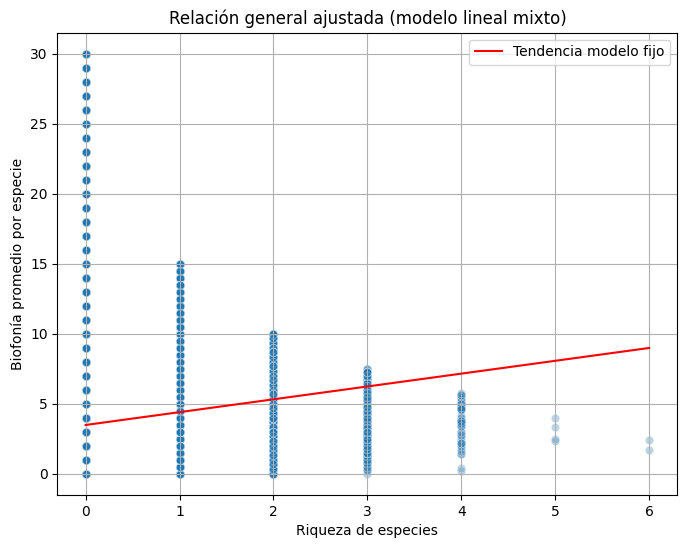

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,6))
sns.scatterplot(x='species_count', y='biophony_per_species', data=bio, alpha=0.3)

# Generar valores para la línea de regresión fija
x_vals = np.linspace(bio['species_count'].min(), bio['species_count'].max(), 100)
intercept = 3.481  # según tu modelo
slope = 0.917
y_vals = intercept + slope * x_vals

plt.plot(x_vals, y_vals, color='red', label='Tendencia modelo fijo')
plt.xlabel('Riqueza de especies')
plt.ylabel('Biofonía promedio por especie')
plt.title('Relación general ajustada (modelo lineal mixto)')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# Asumiendo que `result` es el objeto que contiene el modelo ajustado, por ejemplo:
# result = model.fit()

# Extraer los efectos aleatorios por grupo (sitio)
random_effects = result.random_effects

# random_effects es un diccionario con clave=grupo (site) y valor=efectos aleatorios (normalmente un arreglo o diccionario)

# Para convertirlo a DataFrame:
import pandas as pd

# Construir lista de filas con sitio y efecto aleatorio
rows = []
for site, effects in random_effects.items():
    # Si es un array o dict, tomar el intercepto aleatorio (asumiendo que es el primer elemento)
    if isinstance(effects, dict):
        intercept = effects.get('Group', list(effects.values())[0])  # puede variar la clave
    else:
        intercept = effects[0] if len(effects) > 0 else effects
    rows.append({'site': site, 'random_intercept': intercept})

random_effects_df = pd.DataFrame(rows)

print(random_effects_df.head())


           site  random_intercept
0  P01_SMM09721         -2.269679
1  P02_SMM09261          1.874681
2  P03_SMM09499         -1.533554
3  P04_SMM09557         -0.023430
4  P07_SMM09344         -0.782817


/tmp/ipykernel_32431/3309658689.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = effects[0] if len(effects) > 0 else effects


In [11]:
# Suponiendo que tienes un DataFrame `random_effects` con índices de sitios ('site') y valores de interceptos aleatorios
# Ejemplo minimalista (deberías extraerlos de tu modelo real)


plt.figure(figsize=(10,7))

for site, re_intercept in random_effects_df.items():
    y_site = (intercept + re_intercept) + slope * x_vals
    plt.plot(x_vals, y_site, label=site)

plt.xlabel('Riqueza de especies')
plt.ylabel('Biofonía promedio por especie')
plt.title('Relación entre riqueza y biofonía por sitio (efectos aleatorios)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


TypeError: unsupported operand type(s) for +: 'float' and 'str'

<Figure size 1000x700 with 0 Axes>